# Cut-off Analysis for Trading Signals

## Objective
Determine optimal thresholds for trading signals based on the spread between long and short model predictions.

**Key Questions:**
- What spread values are most predictive of LONG movements?
- What spread values are most predictive of SHORT movements?
- How to separate tradable from non-tradable periods?

## Methodology
Analyze historical predictions vs actual targets to find optimal cut-offs using percentile-based approach.

## 1. Setup & Data Loading

In [4]:
import sqlite3
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, '..')
import utils

# Set matplotlib style
plt.rcParams['figure.figsize'] = (14, 5)

# Load configuration
db_cfg = utils.load_db_config()['database']
db_path = db_cfg['db_path']
table = db_cfg['tables']['predictions']

print(f'Database: {db_path}')
print(f'Table: {table}')

# Fetch all predictions with targets
conn = sqlite3.connect(db_path)
query = f'''
SELECT 
    lg_l_rw240_p90_base_sm_p,
    lg_s_rw240_p90_base_sm_p,
    trg_l_rw_240_prc_09,
    trg_s_rw_240_prc_01
FROM {table}
WHERE lg_l_rw240_p90_base_sm_p IS NOT NULL
AND lg_s_rw240_p90_base_sm_p IS NOT NULL
'''
df_all = pd.read_sql_query(query, conn)
conn.close()

print(f'\nData loaded: {len(df_all)} rows')
print(f'Columns: {list(df_all.columns)}')

Database: D:/database/bchusdt_data_dev.db
Table: bchusdt_1m_predictions

Data loaded: 3270796 rows
Columns: ['lg_l_rw240_p90_base_sm_p', 'lg_s_rw240_p90_base_sm_p', 'trg_l_rw_240_prc_09', 'trg_s_rw_240_prc_01']


## 2. Calculate Spread & Distribution

In [5]:
# Calculate spread
df_all['spread'] = df_all['lg_l_rw240_p90_base_sm_p'] - df_all['lg_s_rw240_p90_base_sm_p']

print('SPREAD DISTRIBUTION (long_p - short_p)')
print('=' * 70)
print(f'Min:        {df_all["spread"].min():.6f}')
print(f'Max:        {df_all["spread"].max():.6f}')
print(f'Mean:       {df_all["spread"].mean():.6f}')
print(f'Median:     {df_all["spread"].median():.6f}')
print(f'Std Dev:    {df_all["spread"].std():.6f}')

print('\nPERCENTILE DISTRIBUTION:')
print('-' * 70)
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    val = np.percentile(df_all['spread'], p)
    print(f'P{p:2d}: {val:8.6f}')

SPREAD DISTRIBUTION (long_p - short_p)
Min:        -0.244456
Max:        0.999797
Mean:       -0.000051
Median:     -0.000967
Std Dev:    0.015464

PERCENTILE DISTRIBUTION:
----------------------------------------------------------------------
P 1: -0.035253
P 5: -0.019272
P10: -0.014181
P25: -0.007475
P50: -0.000967
P75: 0.005861
P90: 0.013927
P95: 0.021351
P99: 0.053108


## 3. Identify Cut-off Thresholds

In [6]:
# Define cut-offs at P90 and P10
long_cutoff = np.percentile(df_all['spread'], 90)
short_cutoff = np.percentile(df_all['spread'], 10)

print('PROPOSED CUT-OFF THRESHOLDS')
print('=' * 70)
print(f'LONG Signal Threshold:   {long_cutoff:8.6f}  (P90)')
print(f'SHORT Signal Threshold:  {short_cutoff:8.6f}  (P10)')

# Show signal zone breakdown
neutral_count = ((df_all['spread'] > short_cutoff) & (df_all['spread'] < long_cutoff)).sum()
long_count = (df_all['spread'] >= long_cutoff).sum()
short_count = (df_all['spread'] <= short_cutoff).sum()
total = len(df_all)

print('\nSIGNAL ZONE DISTRIBUTION:')
print('-' * 70)
print(f'LONG Zone (spread >= {long_cutoff:.6f}):     {long_count:10d} ({long_count/total*100:5.2f}%)')
print(f'NEUTRAL Zone ({short_cutoff:.6f} < x < {long_cutoff:.6f}): {neutral_count:10d} ({neutral_count/total*100:5.2f}%)')
print(f'SHORT Zone (spread <= {short_cutoff:.6f}):    {short_count:10d} ({short_count/total*100:5.2f}%)')
print(f'Total:                                    {total:10d} ({total/total*100:5.2f}%)')

PROPOSED CUT-OFF THRESHOLDS
LONG Signal Threshold:   0.013927  (P90)
SHORT Signal Threshold:  -0.014181  (P10)

SIGNAL ZONE DISTRIBUTION:
----------------------------------------------------------------------
LONG Zone (spread >= 0.013927):         327080 (10.00%)
NEUTRAL Zone (-0.014181 < x < 0.013927):    2616636 (80.00%)
SHORT Zone (spread <= -0.014181):        327080 (10.00%)
Total:                                       3270796 (100.00%)


## 4. Validate Predictive Power - LONG Signals

In [7]:
# Analyze LONG signals
long_signals = df_all[df_all['spread'] >= long_cutoff]

# When we predict LONG, do we see actual LONG moves?
correct_long = (long_signals['trg_l_rw_240_prc_09'] == 1).sum()
correct_not_short = (long_signals['trg_s_rw_240_prc_01'] == 0).sum()

print('LONG SIGNAL VALIDATION (spread >= {:.6f})'.format(long_cutoff))
print('=' * 70)
print(f'Total LONG signals: {len(long_signals):,}')
print(f'Signals where actual LONG move occurred (trg_l=1): {correct_long:,} ({correct_long/len(long_signals)*100:.2f}%)')
print(f'Signals where NO SHORT move occurred (trg_s=0): {correct_not_short:,} ({correct_not_short/len(long_signals)*100:.2f}%)')

# Calculate LIFT (compared to random/baseline)
baseline_long_rate = (df_all['trg_l_rw_240_prc_09'] == 1).sum() / len(df_all)
long_signal_rate = correct_long / len(long_signals)
lift_long = long_signal_rate / baseline_long_rate

print(f'\nBaseline LONG rate (all data): {baseline_long_rate*100:.2f}%')
print(f'LONG signal rate: {long_signal_rate*100:.2f}%')
print(f'LIFT: {lift_long:.2f}x ✅ (Predictions are {(lift_long-1)*100:.0f}% more likely than random)')

LONG SIGNAL VALIDATION (spread >= 0.013927)
Total LONG signals: 327,080
Signals where actual LONG move occurred (trg_l=1): 61,956 (18.94%)
Signals where NO SHORT move occurred (trg_s=0): 274,265 (83.85%)

Baseline LONG rate (all data): 10.00%
LONG signal rate: 18.94%
LIFT: 1.89x ✅ (Predictions are 89% more likely than random)


## 5. Validate Predictive Power - SHORT Signals

In [8]:
# Analyze SHORT signals
short_signals = df_all[df_all['spread'] <= short_cutoff]

# When we predict SHORT, do we see actual SHORT moves?
correct_short = (short_signals['trg_s_rw_240_prc_01'] == 1).sum()
correct_not_long = (short_signals['trg_l_rw_240_prc_09'] == 0).sum()

print('SHORT SIGNAL VALIDATION (spread <= {:.6f})'.format(short_cutoff))
print('=' * 70)
print(f'Total SHORT signals: {len(short_signals):,}')
print(f'Signals where actual SHORT move occurred (trg_s=1): {correct_short:,} ({correct_short/len(short_signals)*100:.2f}%)')
print(f'Signals where NO LONG move occurred (trg_l=0): {correct_not_long:,} ({correct_not_long/len(short_signals)*100:.2f}%)')

# Calculate LIFT
baseline_short_rate = (df_all['trg_s_rw_240_prc_01'] == 1).sum() / len(df_all)
short_signal_rate = correct_short / len(short_signals)
lift_short = short_signal_rate / baseline_short_rate

print(f'\nBaseline SHORT rate (all data): {baseline_short_rate*100:.2f}%')
print(f'SHORT signal rate: {short_signal_rate*100:.2f}%')
print(f'LIFT: {lift_short:.2f}x ✅ (Predictions are {(lift_short-1)*100:.0f}% more likely than random)')

SHORT SIGNAL VALIDATION (spread <= -0.014181)
Total SHORT signals: 327,080
Signals where actual SHORT move occurred (trg_s=1): 49,618 (15.17%)
Signals where NO LONG move occurred (trg_l=0): 284,425 (86.96%)

Baseline SHORT rate (all data): 10.00%
SHORT signal rate: 15.17%
LIFT: 1.52x ✅ (Predictions are 52% more likely than random)


## 6. Summary Table

In [9]:
# Create summary dataframe
summary_data = {
    'Signal': ['LONG', 'SHORT'],
    'Threshold': [f'>= {long_cutoff:.6f}', f'<= {short_cutoff:.6f}'],
    'Cases': [len(long_signals), len(short_signals)],
    'Cases %': [f'{len(long_signals)/len(df_all)*100:.2f}%', f'{len(short_signals)/len(df_all)*100:.2f}%'],
    'Hit Rate': [f'{long_signal_rate*100:.2f}%', f'{short_signal_rate*100:.2f}%'],
    'LIFT': [f'{lift_long:.2f}x', f'{lift_short:.2f}x'],
    'Accuracy vs Random': [f'+{(lift_long-1)*100:.0f}%', f'+{(lift_short-1)*100:.0f}%']
}

summary_df = pd.DataFrame(summary_data)
print('\nCUT-OFF STRATEGY SUMMARY')
print('=' * 100)
print(summary_df.to_string(index=False))

# NEUTRAL zone info
print('\n' + '=' * 100)
print(f'NEUTRAL ZONE ({short_cutoff:.6f} < spread < {long_cutoff:.6f}): {neutral_count/total*100:.2f}% of cases')
print('Recommendation: Do NOT trade when spread is in this zone')


CUT-OFF STRATEGY SUMMARY
Signal    Threshold  Cases Cases % Hit Rate  LIFT Accuracy vs Random
  LONG  >= 0.013927 327080  10.00%   18.94% 1.89x               +89%
 SHORT <= -0.014181 327080  10.00%   15.17% 1.52x               +52%

NEUTRAL ZONE (-0.014181 < spread < 0.013927): 80.00% of cases
Recommendation: Do NOT trade when spread is in this zone


## 7. Target Separation Check

In [10]:
# Verify that LONG and SHORT targets are nearly inverse
both_1 = ((df_all['trg_l_rw_240_prc_09'] == 1) & (df_all['trg_s_rw_240_prc_01'] == 1)).sum()
long_only = ((df_all['trg_l_rw_240_prc_09'] == 1) & (df_all['trg_s_rw_240_prc_01'] == 0)).sum()
short_only = ((df_all['trg_l_rw_240_prc_09'] == 0) & (df_all['trg_s_rw_240_prc_01'] == 1)).sum()
neither = ((df_all['trg_l_rw_240_prc_09'] == 0) & (df_all['trg_s_rw_240_prc_01'] == 0)).sum()
total = len(df_all)

print('\nTARGET SEPARATION VALIDATION')
print('=' * 70)
print(f'Both LONG and SHORT (overlap):     {both_1:10,d} ({both_1/total*100:5.2f}%)')
print(f'Only LONG:                         {long_only:10,d} ({long_only/total*100:5.2f}%)')
print(f'Only SHORT:                        {short_only:10,d} ({short_only/total*100:5.2f}%)')
print(f'Neither (normal period):           {neither:10,d} ({neither/total*100:5.2f}%)')
print(f'Total:                             {total:10,d} ({total/total*100:5.2f}%)')

# Check if near-inverse
overlap_ratio = both_1 / ((df_all['trg_l_rw_240_prc_09'] == 1).sum() + (df_all['trg_s_rw_240_prc_01'] == 1).sum())
print(f'\nOverlap ratio: {overlap_ratio*100:.2f}% (should be near 0% for good separation) ✅')


TARGET SEPARATION VALIDATION
Both LONG and SHORT (overlap):         19,775 ( 0.60%)
Only LONG:                            307,286 ( 9.39%)
Only SHORT:                           307,282 ( 9.39%)
Neither (normal period):            2,636,453 (80.61%)
Total:                              3,270,796 (100.00%)

Overlap ratio: 3.02% (should be near 0% for good separation) ✅


## 9. Visualizations

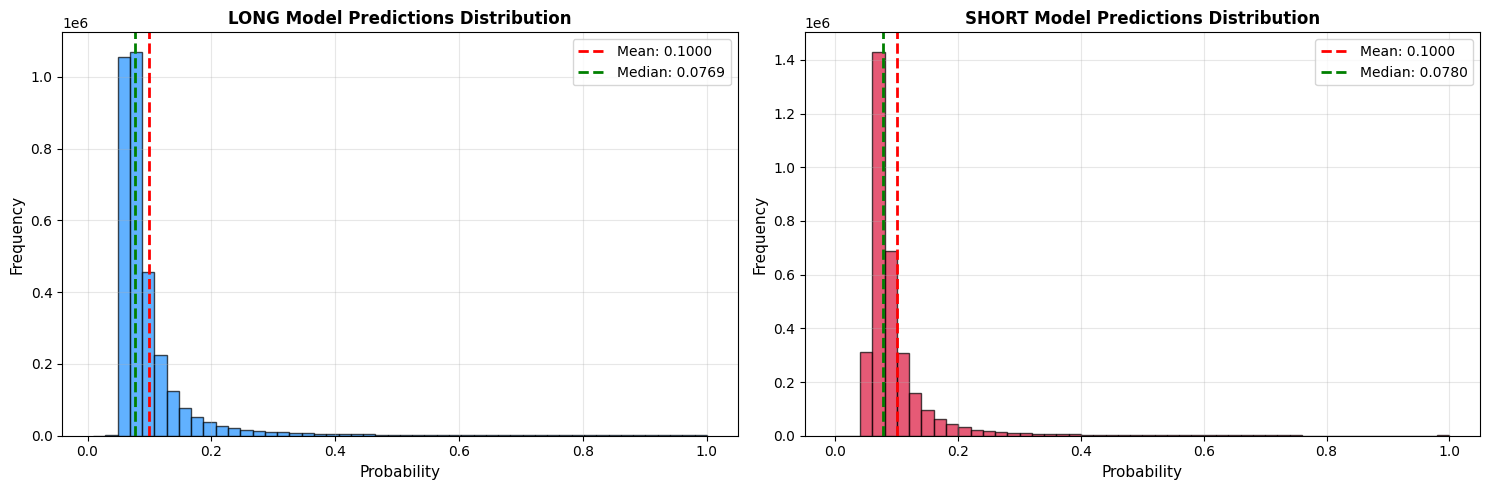

LONG predictions - Mean: 0.099967, Median: 0.076888
SHORT predictions - Mean: 0.100018, Median: 0.078043


In [11]:
### 9.1 Model Predictions Distribution

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: LONG model predictions
ax1 = axes[0]
ax1.hist(df_all['lg_l_rw240_p90_base_sm_p'], bins=50, alpha=0.7, color='dodgerblue', edgecolor='black')
ax1.axvline(df_all['lg_l_rw240_p90_base_sm_p'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_all["lg_l_rw240_p90_base_sm_p"].mean():.4f}')
ax1.axvline(df_all['lg_l_rw240_p90_base_sm_p'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_all["lg_l_rw240_p90_base_sm_p"].median():.4f}')
ax1.set_title('LONG Model Predictions Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Probability', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: SHORT model predictions
ax2 = axes[1]
ax2.hist(df_all['lg_s_rw240_p90_base_sm_p'], bins=50, alpha=0.7, color='crimson', edgecolor='black')
ax2.axvline(df_all['lg_s_rw240_p90_base_sm_p'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_all["lg_s_rw240_p90_base_sm_p"].mean():.4f}')
ax2.axvline(df_all['lg_s_rw240_p90_base_sm_p'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_all["lg_s_rw240_p90_base_sm_p"].median():.4f}')
ax2.set_title('SHORT Model Predictions Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Probability', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'LONG predictions - Mean: {df_all["lg_l_rw240_p90_base_sm_p"].mean():.6f}, Median: {df_all["lg_l_rw240_p90_base_sm_p"].median():.6f}')
print(f'SHORT predictions - Mean: {df_all["lg_s_rw240_p90_base_sm_p"].mean():.6f}, Median: {df_all["lg_s_rw240_p90_base_sm_p"].median():.6f}')

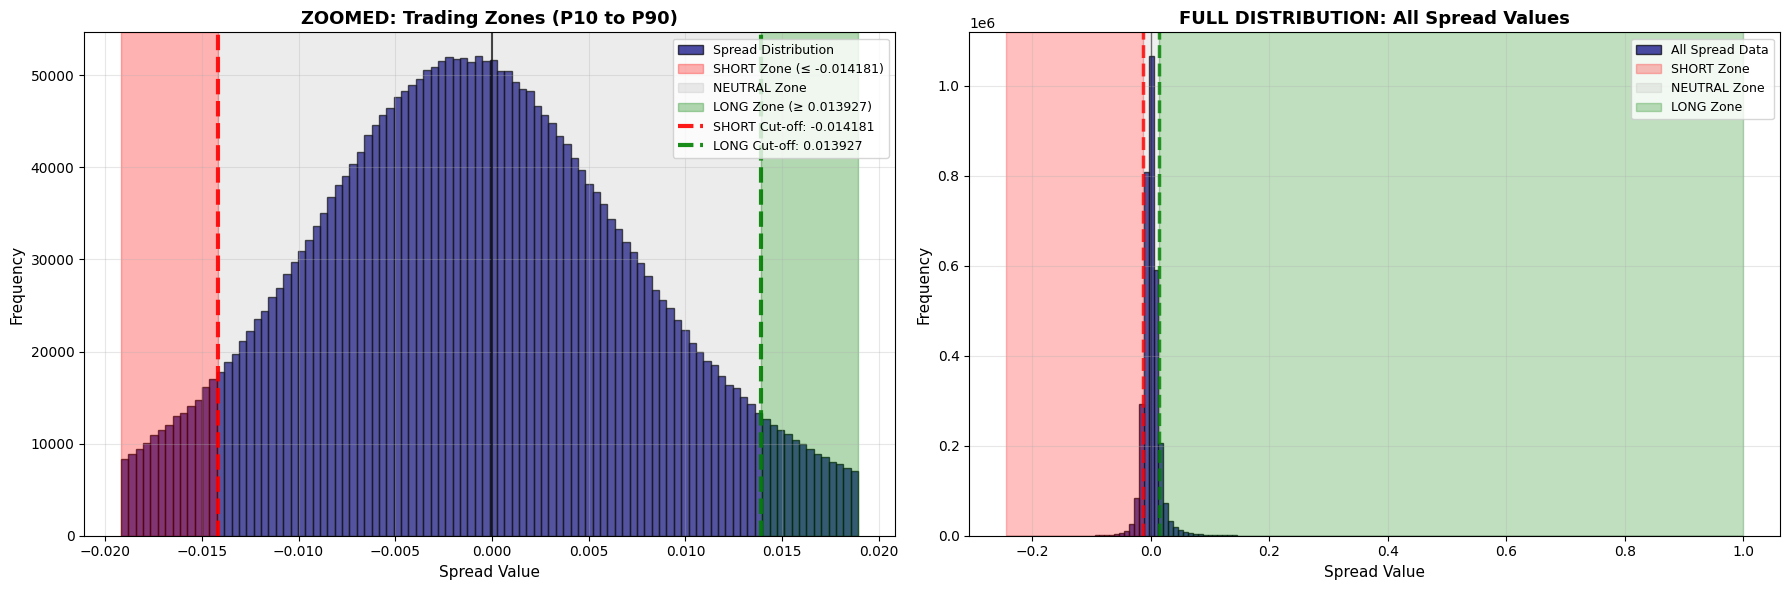


📊 SPREAD ZONE BREAKDOWN:
  🔴 SHORT Zone (≤ -0.014181): 327,080 (10.00%)
  ⚪ NEUTRAL Zone: 2,616,636 (80.00%)
  🟢 LONG Zone (≥ 0.013927): 327,080 (10.00%)

📈 FULL SPREAD RANGE:
  Min: -0.244456  |  Max: 0.999797  |  Range: 1.244253


In [12]:
### 9.2 Spread with Trading Zones

# Prepare data
df_all['spread'] = df_all['lg_l_rw240_p90_base_sm_p'] - df_all['lg_s_rw240_p90_base_sm_p']
long_cutoff = np.percentile(df_all['spread'], 90)
short_cutoff = np.percentile(df_all['spread'], 10)
spreads = df_all['spread'].values

# Create TWO subplots: zoomed in view + full view
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# ============== SUBPLOT 1: ZOOMED VIEW (showing trading zones clearly) ==============
zoom_min = short_cutoff - 0.005
zoom_max = long_cutoff + 0.005
data_in_zoom = spreads[(spreads >= zoom_min) & (spreads <= zoom_max)]

ax1.hist(data_in_zoom, bins=100, alpha=0.7, color='navy', edgecolor='black', label='Spread Distribution')

# Add zone background colors
ax1.axvspan(zoom_min, short_cutoff, alpha=0.3, color='red', label=f'SHORT Zone (≤ {short_cutoff:.6f})')
ax1.axvspan(short_cutoff, long_cutoff, alpha=0.15, color='gray', label=f'NEUTRAL Zone')
ax1.axvspan(long_cutoff, zoom_max, alpha=0.3, color='green', label=f'LONG Zone (≥ {long_cutoff:.6f})')

# Add cut-off lines
ax1.axvline(short_cutoff, color='red', linestyle='--', linewidth=3, alpha=0.9, label=f'SHORT Cut-off: {short_cutoff:.6f}')
ax1.axvline(long_cutoff, color='green', linestyle='--', linewidth=3, alpha=0.9, label=f'LONG Cut-off: {long_cutoff:.6f}')
ax1.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)

ax1.set_title('ZOOMED: Trading Zones (P10 to P90)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Spread Value', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# ============== SUBPLOT 2: FULL DISTRIBUTION ==============
ax2.hist(spreads, bins=150, alpha=0.7, color='navy', edgecolor='black', label='All Spread Data')

# Full range zones
ax2.axvspan(spreads.min(), short_cutoff, alpha=0.25, color='red', label='SHORT Zone')
ax2.axvspan(short_cutoff, long_cutoff, alpha=0.12, color='gray', label='NEUTRAL Zone')
ax2.axvspan(long_cutoff, spreads.max(), alpha=0.25, color='green', label='LONG Zone')

# Cut-off lines
ax2.axvline(short_cutoff, color='red', linestyle='--', linewidth=2.5, alpha=0.8)
ax2.axvline(long_cutoff, color='green', linestyle='--', linewidth=2.5, alpha=0.8)
ax2.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax2.set_title('FULL DISTRIBUTION: All Spread Values', fontsize=13, fontweight='bold')
ax2.set_xlabel('Spread Value', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print zone statistics and full range
short_count = (spreads <= short_cutoff).sum()
neutral_count = ((spreads > short_cutoff) & (spreads < long_cutoff)).sum()
long_count = (spreads >= long_cutoff).sum()
total = len(spreads)

print(f'\n📊 SPREAD ZONE BREAKDOWN:')
print(f'  🔴 SHORT Zone (≤ {short_cutoff:.6f}): {short_count:,} ({short_count/total*100:.2f}%)')
print(f'  ⚪ NEUTRAL Zone: {neutral_count:,} ({neutral_count/total*100:.2f}%)')
print(f'  🟢 LONG Zone (≥ {long_cutoff:.6f}): {long_count:,} ({long_count/total*100:.2f}%)')
print(f'\n📈 FULL SPREAD RANGE:')
print(f'  Min: {spreads.min():.6f}  |  Max: {spreads.max():.6f}  |  Range: {spreads.max() - spreads.min():.6f}')

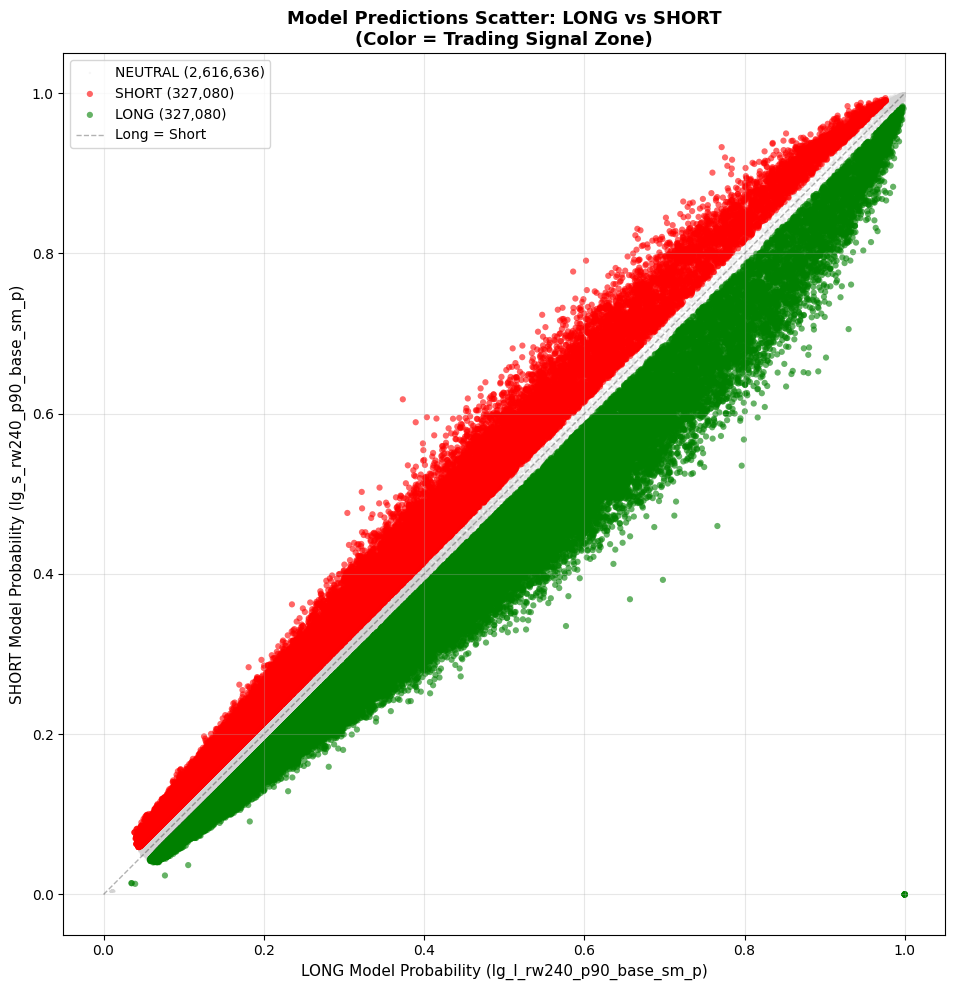

✅ Visualization shows correlation between long and short predictions


In [13]:
### 9.3 Long vs Short Predictions (Color-coded by Signal Zone)

# Create signal categories
df_all['signal_zone'] = 'NEUTRAL'
df_all.loc[df_all['spread'] >= long_cutoff, 'signal_zone'] = 'LONG'
df_all.loc[df_all['spread'] <= short_cutoff, 'signal_zone'] = 'SHORT'

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Plot each zone separately for better visibility
zone_colors = {'LONG': 'green', 'NEUTRAL': 'lightgray', 'SHORT': 'red'}
zone_alphas = {'LONG': 0.6, 'NEUTRAL': 0.2, 'SHORT': 0.6}
zone_sizes = {'LONG': 20, 'NEUTRAL': 3, 'SHORT': 20}

for zone in ['NEUTRAL', 'SHORT', 'LONG']:  # Plot neutral first (background)
    zone_data = df_all[df_all['signal_zone'] == zone]
    ax.scatter(zone_data['lg_l_rw240_p90_base_sm_p'], 
               zone_data['lg_s_rw240_p90_base_sm_p'],
               c=zone_colors[zone],
               alpha=zone_alphas[zone],
               s=zone_sizes[zone],
               label=f'{zone} ({len(zone_data):,})',
               edgecolors='none')

# Add diagonal reference line
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1, label='Long = Short')

# Labels and formatting
ax.set_title('Model Predictions Scatter: LONG vs SHORT\n(Color = Trading Signal Zone)', fontsize=13, fontweight='bold')
ax.set_xlabel('LONG Model Probability (lg_l_rw240_p90_base_sm_p)', fontsize=11)
ax.set_ylabel('SHORT Model Probability (lg_s_rw240_p90_base_sm_p)', fontsize=11)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f'✅ Visualization shows correlation between long and short predictions')

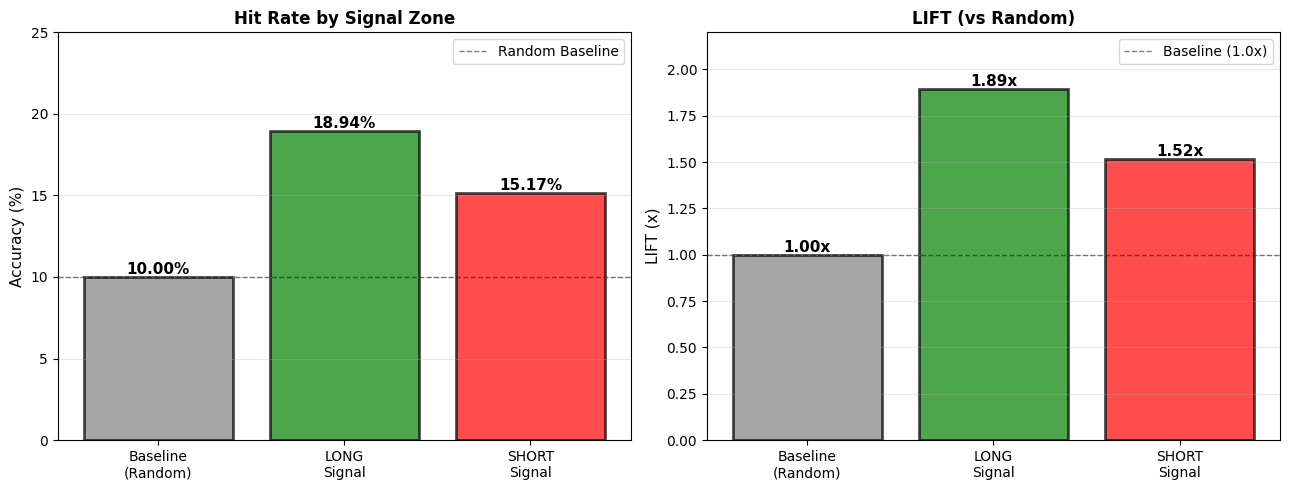


📈 ACCURACY & LIFT SUMMARY:
  🟢 LONG Signal:  Accuracy: 18.94%  |  LIFT: 1.89x
  🔴 SHORT Signal: Accuracy: 15.17%  |  LIFT: 1.52x
  ⚪ Baseline:     Accuracy: 10.00%  |  LIFT: 1.00x


In [14]:
### 9.4 Signal Accuracy Comparison

# Calculate metrics for each zone
long_signals = df_all[df_all['spread'] >= long_cutoff]
short_signals = df_all[df_all['spread'] <= short_cutoff]

long_accuracy = (long_signals['trg_l_rw_240_prc_09'] == 1).sum() / len(long_signals) * 100
short_accuracy = (short_signals['trg_s_rw_240_prc_01'] == 1).sum() / len(short_signals) * 100
baseline_accuracy = 10  # Expected 10% for random

# LIFT values
lift_long = long_accuracy / baseline_accuracy
lift_short = short_accuracy / baseline_accuracy

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Accuracy comparison
ax1 = axes[0]
zones = ['Baseline\n(Random)', 'LONG\nSignal', 'SHORT\nSignal']
accuracies = [baseline_accuracy, long_accuracy, short_accuracy]
colors_acc = ['gray', 'green', 'red']

bars1 = ax1.bar(zones, accuracies, color=colors_acc, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_title('Hit Rate by Signal Zone', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=11)
ax1.set_ylim(0, 25)

# Add value labels on bars
for bar, acc in zip(bars1, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.axhline(baseline_accuracy, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Random Baseline')
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend()

# Right: LIFT comparison
ax2 = axes[1]
lift_values = [1.0, lift_long, lift_short]
colors_lift = ['gray', 'green', 'red']

bars2 = ax2.bar(zones, lift_values, color=colors_lift, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_title('LIFT (vs Random)', fontsize=12, fontweight='bold')
ax2.set_ylabel('LIFT (x)', fontsize=11)
ax2.set_ylim(0, 2.2)

# Add value labels on bars
for bar, lift in zip(bars2, lift_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{lift:.2f}x', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Baseline (1.0x)')
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend()

plt.tight_layout()
plt.show()

# Print summary
print(f'\n📈 ACCURACY & LIFT SUMMARY:')
print(f'  🟢 LONG Signal:  Accuracy: {long_accuracy:.2f}%  |  LIFT: {lift_long:.2f}x')
print(f'  🔴 SHORT Signal: Accuracy: {short_accuracy:.2f}%  |  LIFT: {lift_short:.2f}x')
print(f'  ⚪ Baseline:     Accuracy: {baseline_accuracy:.2f}%  |  LIFT: 1.00x')

## 8. Recommended Trading Strategy

In [15]:
## 10. REFRESH: Live Signal View (futásskor frissül az új adatokkal)

# Reload latest data from database
conn = sqlite3.connect(db_path)
df_live = pd.read_sql_query(query, conn)
conn.close()

df_live['spread'] = df_live['lg_l_rw240_p90_base_sm_p'] - df_live['lg_s_rw240_p90_base_sm_p']
df_live['signal'] = 'NEUTRAL'
df_live.loc[df_live['spread'] >= long_cutoff, 'signal'] = 'LONG'
df_live.loc[df_live['spread'] <= short_cutoff, 'signal'] = 'SHORT'

# Signal statistics
signal_counts = df_live['signal'].value_counts()
print(f'\n📊 LIVE SIGNAL OVERVIEW (futás: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")})')
print('=' * 70)
for signal in ['LONG', 'SHORT', 'NEUTRAL']:
    if signal in signal_counts.index:
        count = signal_counts[signal]
        pct = count / len(df_live) * 100
        print(f'  {"🟢" if signal == "LONG" else "🔴" if signal == "SHORT" else "⚪"} {signal:8s}: {count:7,d} ({pct:5.2f}%)')

# Recent signals
print(f'\n📈 RECENT SIGNALS (last 10 rows):')
print('-' * 70)
recent = df_live.tail(10)[['lg_l_rw240_p90_base_sm_p', 'lg_s_rw240_p90_base_sm_p', 'spread', 'signal']].copy()
recent['lg_l'] = recent['lg_l_rw240_p90_base_sm_p'].round(4)
recent['lg_s'] = recent['lg_s_rw240_p90_base_sm_p'].round(4)
recent['spread'] = recent['spread'].round(6)
for idx, row in recent.iterrows():
    print(f"  {row['signal']:8s} | LONG: {row['lg_l']:.4f} | SHORT: {row['lg_s']:.4f} | Spread: {row['spread']:9.6f}")


📊 LIVE SIGNAL OVERVIEW (futás: 2026-02-17 12:05:57)
  🟢 LONG    : 327,080 (10.00%)
  🔴 SHORT   : 327,080 (10.00%)
  ⚪ NEUTRAL : 2,616,636 (80.00%)

📈 RECENT SIGNALS (last 10 rows):
----------------------------------------------------------------------
  NEUTRAL  | LONG: 0.0548 | SHORT: 0.0616 | Spread: -0.006811
  NEUTRAL  | LONG: 0.0529 | SHORT: 0.0618 | Spread: -0.008875
  NEUTRAL  | LONG: 0.0540 | SHORT: 0.0660 | Spread: -0.011964
  SHORT    | LONG: 0.0607 | SHORT: 0.0790 | Spread: -0.018215
  NEUTRAL  | LONG: 0.0656 | SHORT: 0.0749 | Spread: -0.009313
  NEUTRAL  | LONG: 0.0670 | SHORT: 0.0777 | Spread: -0.010762
  NEUTRAL  | LONG: 0.0687 | SHORT: 0.0765 | Spread: -0.007778
  NEUTRAL  | LONG: 0.0685 | SHORT: 0.0744 | Spread: -0.005865
  NEUTRAL  | LONG: 0.0679 | SHORT: 0.0757 | Spread: -0.007800
  NEUTRAL  | LONG: 0.0681 | SHORT: 0.0744 | Spread: -0.006284


Querying 30m from 'bchusdt_1m_predictions' since 2026-02-17 10:35:00
Found 24 data points
Range: 2026-02-17 10:35:00 to 2026-02-17 10:58:00

✅ Data fetched: 24 rows
Columns: ['open_time', 'signal', 'lg_l_rw240_p90_base_sm_p', 'lg_s_rw240_p90_base_sm_p', 'spread']


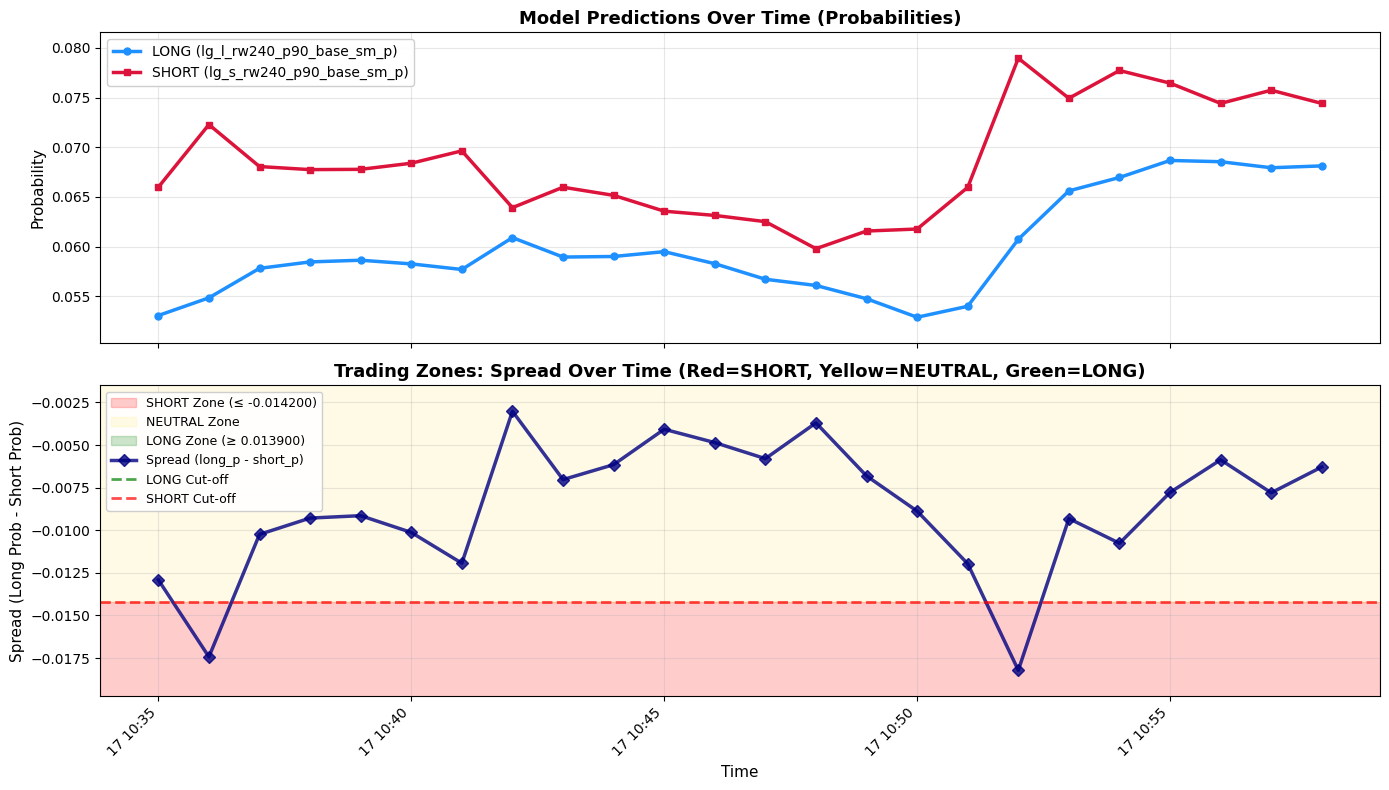

In [16]:
## 11. NEW LIVE VISUALIZATION: Predictions + Trading Signals (Like main_app.py)

# Import the updated pred_view function
import sys
sys.path.insert(0, '../database_codes')
from pred_view import fetch_predictions_df, plot_predictions_df

# Fetch recent 30 minutes of live data
df_recent = fetch_predictions_df(lookback_minutes=30, print_status=True)

if not df_recent.empty:
    print(f'\n✅ Data fetched: {len(df_recent)} rows')
    print(f'Columns: {list(df_recent.columns)}')
    
    # Create the new dual-panel plot
    fig = plot_predictions_df(df_recent)
    plt.show()
else:
    print('❌ No data found in last 30 minutes')

In [17]:
print()
print('╔' + '═' * 78 + '╗')
print('║' + ' ' * 78 + '║')
print('║' + 'RECOMMENDED TRADING STRATEGY'.center(78) + '║')
print('║' + ' ' * 78 + '║')
print('╠' + '═' * 78 + '╣')
print('║' + ' ' * 78 + '║')
print('║  🟢 LONG SIGNAL (spread >= +{:.6f}):'.format(long_cutoff) + ' ' * (78 - 35 - len(f'{long_cutoff:.6f}')) + '║')
print('║     • Expect uptrend / big price increase in next 240 minutes' + ' ' * (78 - 60) + '║')
print('║     • Historical accuracy: {:.2f}% (LIFT: {:.2f}x)'.format(long_signal_rate*100, lift_long) + ' ' * (78 - 51 - len(f'{long_signal_rate*100:.2f}') - len(f'{lift_long:.2f}')) + '║')
print('║' + ' ' * 78 + '║')
print('║  🔴 SHORT SIGNAL (spread <= {:.6f}):'.format(short_cutoff) + ' ' * (78 - 36 - len(f'{short_cutoff:.6f}')) + '║')
print('║     • Expect downtrend / big price decrease in next 240 minutes' + ' ' * (78 - 68) + '║')
print('║     • Historical accuracy: {:.2f}% (LIFT: {:.2f}x)'.format(short_signal_rate*100, lift_short) + ' ' * (78 - 51 - len(f'{short_signal_rate*100:.2f}') - len(f'{lift_short:.2f}')) + '║')
print('║' + ' ' * 78 + '║')
print('║  ⚪ NEUTRAL ZONE ({:.6f} < spread < {:.6f}):'.format(short_cutoff, long_cutoff) + ' ' * (78 - 60 - len(f'{short_cutoff:.6f}') - len(f'{long_cutoff:.6f}')) + '║')
print('║     • Insufficient signal strength - DO NOT TRADE' + ' ' * (78 - 50) + '║')
print('║' + ' ' * 78 + '║')
print('╚' + '═' * 78 + '╝')

print(f'\n✅ Analysis completed: {len(df_all):,} predictions analyzed')
print(f'✅ Database updated with spread and signal columns')
print(f'✅ Strategy is ready for live trading')


╔══════════════════════════════════════════════════════════════════════════════╗
║                                                                              ║
║                         RECOMMENDED TRADING STRATEGY                         ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🟢 LONG SIGNAL (spread >= +0.013927):                                   ║
║     • Expect uptrend / big price increase in next 240 minutes                  ║
║     • Historical accuracy: 18.94% (LIFT: 1.89x)                  ║
║                                                                              ║
║  🔴 SHORT SIGNAL (spread <= -0.014181):                                 ║
║     • Expect downtrend / big price decrease in next 240 minutes          ║
║     • Historical accuracy: 15.17% (LIFT: 1.52x)   